<h2>Assignment 1</h2>

<table style="width:100%; text-align:left;">
<tr>
<td>

### Student 1  
**Name:** Aakanksha Deshpande  
**Student Id:** 25238088  

</td>

<td>

### Student 2  
**Name:** Vijayalaxmi Hubli  
**Student Id:** 25242017  

</td>
</tr>
</table>


## Task 1: Implement Logistic Regression

In [2]:
# Package imports
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [3]:
# Display plots inline
%matplotlib inline

In [4]:
# Initialising Hyperparameters

# alpha = 0.0001 # learning rate
# max_iterations = 10000
# threshold = 1e-8
# N = 500 # No of iterations

In [5]:
# Sigmoid Function (Activation Function)
def sigmoid(z):
    return (1 / (1 + (np.exp(-z))))

In [6]:
# Loss function
def compute_loss(y, y_hat):
    return (- (y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))).item()

In [7]:
# Implementing Logistic Regression Algorithm

def train_logistic_regression(X, Y, alpha, max_iteration, threshold):
    """
    Logistic Regression Learning Algorithm with forward pass and Stochastic Gradient Descent

    Inputs:
    X = training dataset
    Y = target labels
    alpha = learning rate
    max_iteration = no of steps allowed for training
    threshold = stopping criteris
    N = no of iterations to accumulate the loss to check convergence

    Outputs:
    w = learned weights
    b = learned bias
    """
    #---------------------------------
    # Initialising weights and biases
    #---------------------------------
    stopping = False
    J_running = 0
    epoch_number = 0
    J_running_prev = 0
    prev_avg_loss = float("inf")
    iteration = 0
    N,m = X.shape
    w = np.random.normal(0, 0.01, size=(m,1))
    b = 0.01


    #---------------------------------
    # Implementing SGD
    #---------------------------------
    loss = []
    epoch_loss = []
    while not stopping:

        # picking random values from training dataset
        index = np.random.randint(0, N)
        x_i = X[index].reshape(-1,1)
        y_i = Y[index]

        # Implementing Forward propagation stage
        z = np.dot(w.T, x_i) + b
        y_hat = sigmoid(z)

        # Calculate the loss
        J_current = compute_loss(y_i, y_hat)
        loss.append(J_current)
        # Gradient Descent stage:
        # partial deivatives
        dw = (y_hat - y_i) * x_i
        db = y_hat - y_i

        # calculate w and b
        w -= alpha * dw
        b -= alpha * db

        # Checking stopping criteia
        iteration += 1
        J_running += J_current

        if iteration % N == 0:
            epoch_number += 1
            avg_loss = J_running / N
            epoch_loss.append(avg_loss)
            # print("Iteration:", iteration, "Avg Loss:", avg_loss)
            if abs(avg_loss - prev_avg_loss) < threshold:
                print(f"Converged after {epoch_number} epochs ({iteration} iterations)")
                stopping = True
            prev_avg_loss = avg_loss
            J_running = 0
        if iteration  > max_iteration:
            print("Failed to converge!!!")
            stopping = True # Failed to converge
        


    return w, b, loss, epoch_loss


In [8]:
def predict(X, w, b, threshold):
    z = np.dot(X, w) + b
    y_hat = sigmoid(z)
    return (y_hat >= threshold).astype(int)

## Task 2: Testing on Datasets

In [10]:
# Loading Dataset 1
# Use pandas to read the CSV file as a dataframe
df1 = pd.read_csv("/Users/aakankshadeshpande/Documents/Assignments_Sem2/blobs600.csv")

# The y values are those labelled 'Class': extract their values
y1 = df1['Class'].values

# The x values are all other columns
del df1['Class']   # drop the 'Class' column from the dataframe
X1 = df1.values     # convert the remaining columns to a numpy array

In [11]:
# Check its dimensions

print(f"The dimensions of the dataset are: {np.shape(X1)}")

The dimensions of the dataset are: (600, 3)


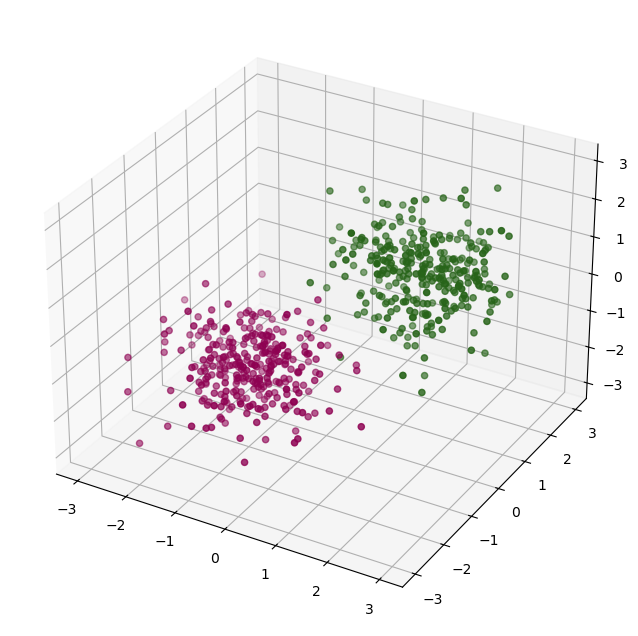

In [12]:
# Plot the dataset in 3D, with colours according to the class label

fig = plt.figure(figsize=(8, 8)) # set the size to 8x8 
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X1[:,0], X1[:,1], X1[:,2], c=y1, cmap="PiYG") # changed the colour map because why not

plt.show()
plt.close(fig)

## Task 3: Implement and test a shallow Neural Network

## Task 4: Tackle a challenging task

## Task 5: Deep Learning Enhancements